# Telco Customer Churn — Deep Business Analysis & Logistic Regression

**Objective:** answer the complete project question bank through a reproducible, leakage-safe workflow.

### Master Question
> Which customer characteristics, service patterns, contract structures, and billing behaviors are associated with customer churn; how accurately can Logistic Regression estimate churn probability; and how can those predictions be translated into interpretable customer-risk segments for business analysis?

This notebook is organized to answer the 18 project sections:
1. Business Problem & Objectives
2. Data Understanding
3. Data Quality & Validation
4. Exploratory Data Analysis
5. Deep Business Analysis
6. Statistical Analysis
7. Feature Engineering & Preprocessing
8. Logistic Regression
9. Model Evaluation
10. Class Imbalance & Threshold Analysis
11. Model Interpretation
12. Probability & Calibration
13. Customer Risk Segmentation
14. Business Impact Analysis
15. Model Robustness & Reliability
16. Model Comparison
17. Final Business Analysis
18. Project Conclusion

## 1. Business Problem & Objectives

Customer churn represents customers who discontinue the service. The analytical goal is not only to predict churn, but to understand observable patterns associated with churn and translate model probabilities into interpretable risk segments.

**Important:** predictive association is not causal evidence.

In [37]:
# Import the libraries used throughout the notebook.
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd() / "src"))

from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

# Add the project-level src directory to the import path.
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from analysis import (
    TARGET,
    ID_COLUMN,
    add_business_features,
    build_logistic_pipeline,
    coefficient_table,
    clean_data,
    evaluate_binary_model,
    load_data,
    risk_segments,
    threshold_table,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Project root:", ROOT)
print("Dataset path:", DATA_PATH)

Project root: E:\telco-customer-churn-logistic-regression
Dataset path: E:\telco-customer-churn-logistic-regression\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


## 2. Data Understanding

This section establishes the dataset dimensions, columns, data types, target definition, and class distribution before any modeling.

In [38]:
# Load the supplied CSV and display its basic structure.
raw = load_data(DATA_PATH)

print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")
display(raw.head())
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "non_null": raw.notna().sum()}))

Rows: 7,043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype,non_null
customerID,str,7043
gender,str,7043
SeniorCitizen,int64,7043
Partner,str,7043
Dependents,str,7043
tenure,int64,7043
PhoneService,str,7043
MultipleLines,str,7043
InternetService,str,7043
OnlineSecurity,str,7043


In [39]:
# Inspect the target distribution and calculate the observed churn rate.
target_counts = raw[TARGET].value_counts(dropna=False)
target_pct = raw[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({
    "customers": target_counts,
    "percentage": target_pct,
})
display(target_summary)

print(f"Observed churn rate: {target_pct.get('Yes', 0):.2f}%")

,customers,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Observed churn rate: 26.54%


## 3. Data Quality & Validation

The source file stores `TotalCharges` as text. Blank values are therefore detectable only after numeric coercion. We also check duplicates, blanks, invalid ranges, uniqueness, and target consistency.

In [40]:
# Run data-quality checks before feature engineering.
clean = clean_data(raw)

quality = pd.DataFrame({
    "dtype": clean.dtypes.astype(str),
    "missing_values": clean.isna().sum(),
    "missing_percent": (clean.isna().mean() * 100).round(3),
    "unique_values": clean.nunique(dropna=False),
})
display(quality)

print("Duplicate rows after cleaning:", clean.duplicated().sum())
print("Unique customer IDs:", clean[ID_COLUMN].nunique())
print("Rows:", len(clean))

,dtype,missing_values,missing_percent,unique_values
customerID,str,0,0.000,7043
gender,str,0,0.000,2
SeniorCitizen,int64,0,0.000,2
Partner,str,0,0.000,2
Dependents,str,0,0.000,2
tenure,int64,0,0.000,73
PhoneService,str,0,0.000,2
MultipleLines,str,0,0.000,3
InternetService,str,0,0.000,3
OnlineSecurity,str,0,0.000,3


Duplicate rows after cleaning: 0
Unique customer IDs: 7043
Rows: 7043


In [41]:
# Identify blank-like source values and validate numerical ranges.
blank_counts = raw.astype("string").apply(
    lambda col: col.str.strip().eq("").sum()
).sort_values(ascending=False)

print("Blank/whitespace-only values by column:")
display(blank_counts[blank_counts > 0])

print("Tenure range:", clean["tenure"].min(), "to", clean["tenure"].max())
print("MonthlyCharges range:", clean["MonthlyCharges"].min(), "to", clean["MonthlyCharges"].max())
print("TotalCharges missing after coercion:", clean["TotalCharges"].isna().sum())
print("Churn classes:", clean[TARGET].dropna().unique().tolist())

Blank/whitespace-only values by column:


TotalCharges    11
dtype: int64

Tenure range: 0 to 72
MonthlyCharges range: 18.25 to 118.75
TotalCharges missing after coercion: 11
Churn classes: ['No', 'Yes']


In [42]:
# Confirm the relationship between TotalCharges, tenure, and monthly charges for data-quality review.
display(
    clean.loc[clean["TotalCharges"].isna(),
              [ID_COLUMN, "tenure", "MonthlyCharges", "TotalCharges", TARGET]]
)

# Imputation is handled inside the modeling pipeline; no target leakage is introduced here.

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


## 4. Exploratory Data Analysis

The next cells answer the core descriptive questions about tenure, charges, demographics, services, contracts, billing, and payment methods.

In [43]:
# Create a numeric churn indicator and business-analysis copy.
analysis_df = add_business_features(clean.copy())
analysis_df["ChurnFlag"] = (analysis_df[TARGET] == "Yes").astype(int)

# Show numerical descriptive statistics.
display(analysis_df[["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.000,9.000000,29.0000,55.000000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.250,35.500000,70.3500,89.850000,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.800,401.450000,1397.4750,3794.737500,8684.80
AvgMonthlySpend,7043.0,64.762906,30.189796,13.775,35.935156,70.3375,90.174158,121.40


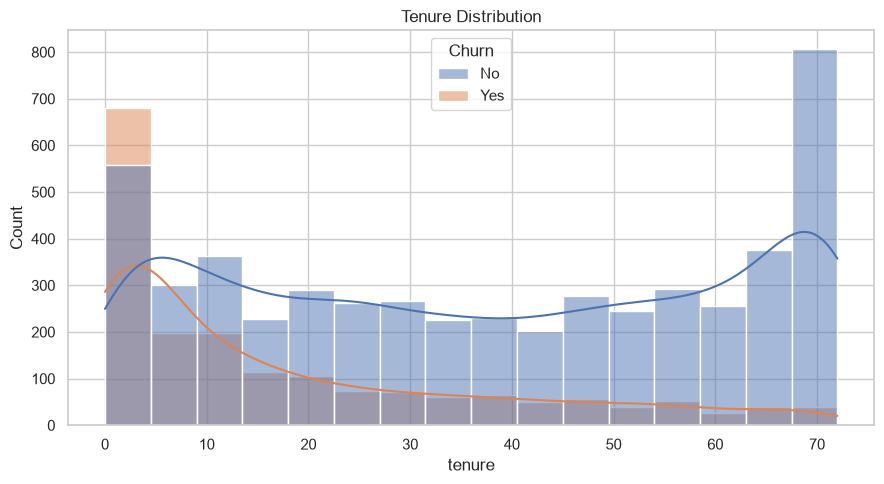

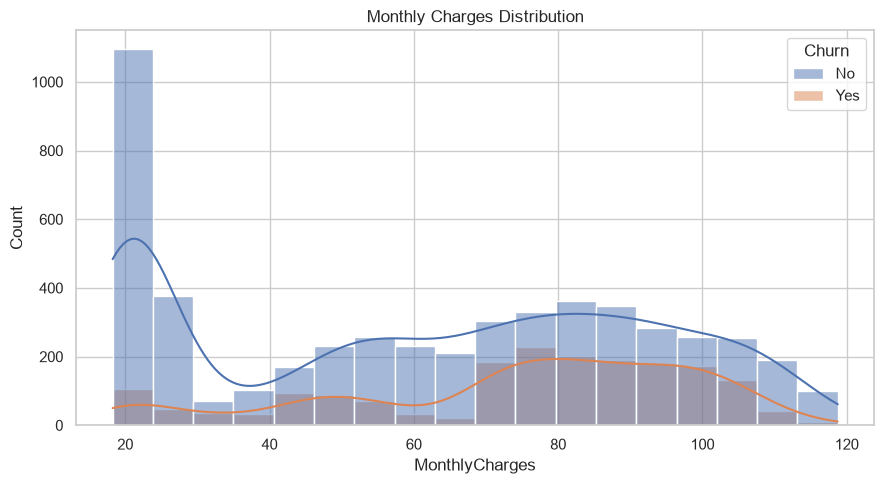

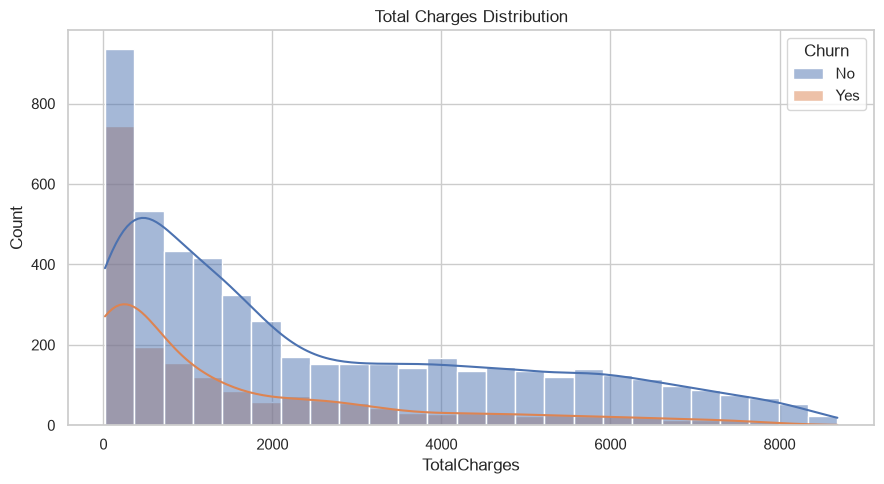

In [44]:
# Plot each primary numerical business variable as an independent figure.
for feature, title in [
    ("tenure", "Tenure Distribution"),
    ("MonthlyCharges", "Monthly Charges Distribution"),
    ("TotalCharges", "Total Charges Distribution"),
]:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=analysis_df, x=feature, hue=TARGET, kde=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [45]:
# Define reusable helper functions for churn-rate analysis.
def churn_rate_by(column, data=analysis_df):
    summary = (
        data.groupby(column, dropna=False)["ChurnFlag"]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "churned_customers", "mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )
    summary["churn_rate"] = summary["churn_rate"].mul(100).round(2)
    return summary

# Key categorical business dimensions.
for col in [
    "Contract", "InternetService", "PaymentMethod",
    "PaperlessBilling", "TechSupport", "OnlineSecurity"
]:
    print(f"\n{col}")
    display(churn_rate_by(col))


Contract


,count,churned_customers,churn_rate
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83



InternetService


,count,churned_customers,churn_rate
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40



PaymentMethod


...

,count,churned_customers,churn_rate
PaperlessBilling,,,
Yes,4171,1400,33.57
No,2872,469,16.33



TechSupport


,count,churned_customers,churn_rate
TechSupport,,,
No,3473,1446,41.64
Yes,2044,310,15.17
No internet service,1526,113,7.40



OnlineSecurity


,count,churned_customers,churn_rate
OnlineSecurity,,,
No,3498,1461,41.77
Yes,2019,295,14.61
No internet service,1526,113,7.40


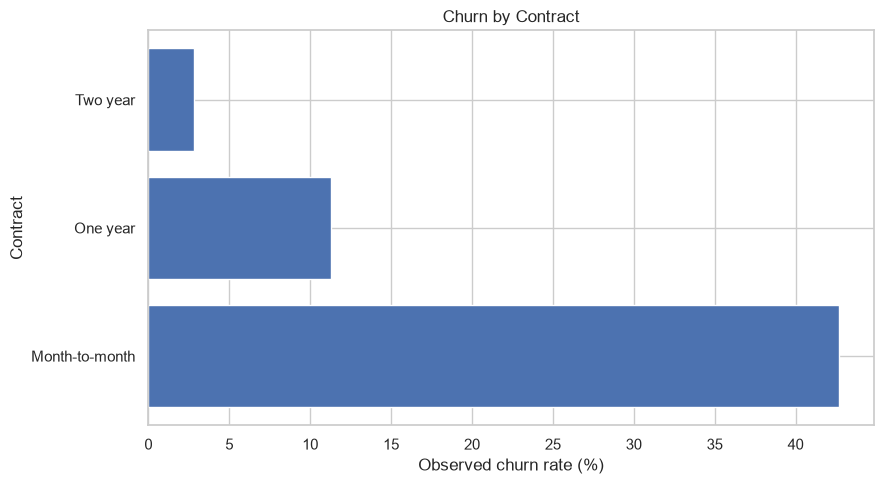

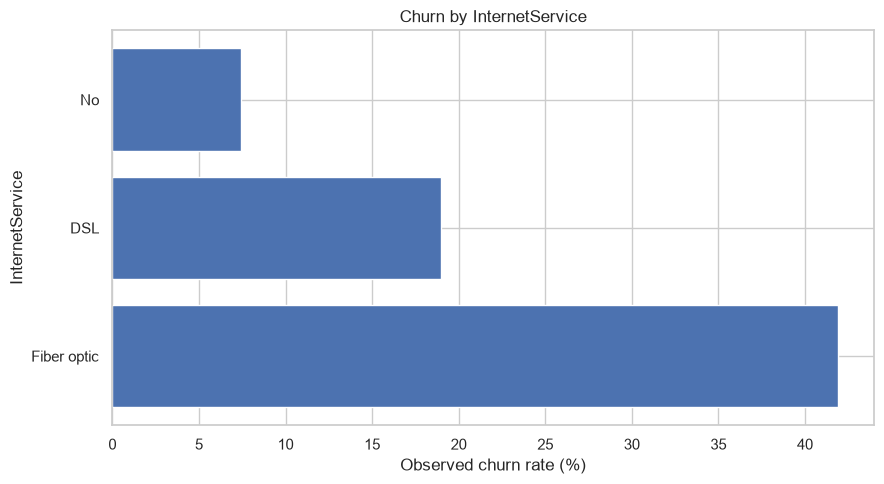

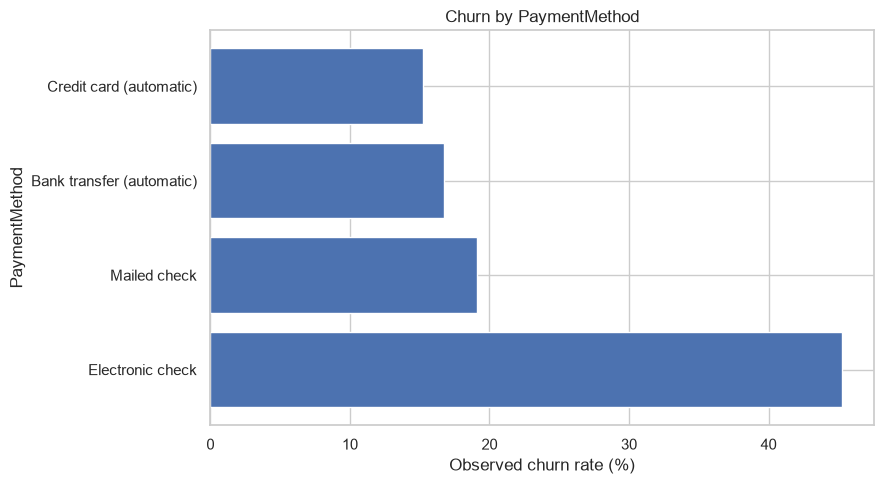

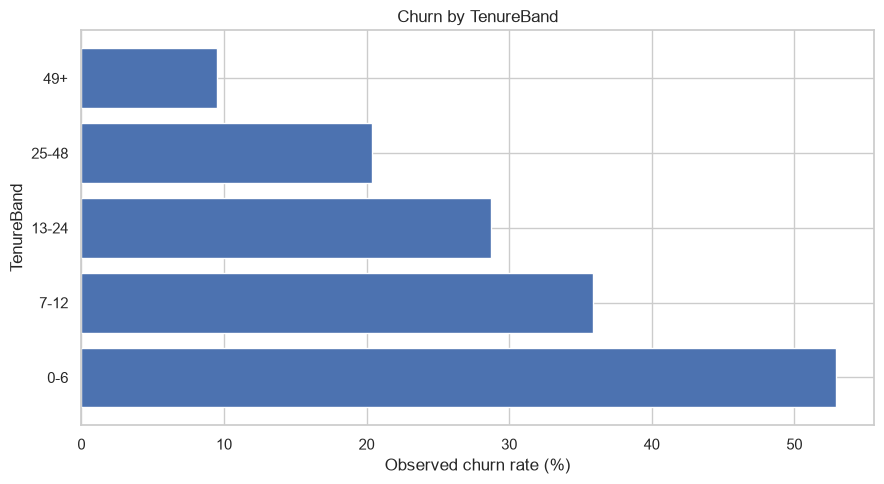

In [46]:
# Visualize each major business segment as an independent horizontal bar chart.
for col in ["Contract", "InternetService", "PaymentMethod", "TenureBand"]:
    summary = churn_rate_by(col).reset_index()
    plt.figure(figsize=(9, 5))
    plt.barh(summary[col].astype(str), summary["churn_rate"])
    plt.xlabel("Observed churn rate (%)")
    plt.ylabel(col)
    plt.title(f"Churn by {col}")
    plt.tight_layout()
    plt.show()

## 5. Deep Business Analysis

This section goes beyond basic EDA. It examines customer lifecycle, service adoption, demographics, billing behavior, and high-exposure segments.

In [47]:
# Compare churn rates by tenure bands, service count, and senior-citizen status.
for col in ["TenureBand", "ServiceCount", "SeniorCitizen", "Partner", "Dependents"]:
    print(f"\n{col}")
    display(churn_rate_by(col))


TenureBand


,count,churned_customers,churn_rate
TenureBand,,,
0-6,1481,784,52.94
7-12,705,253,35.89
13-24,1024,294,28.71
25-48,1594,325,20.39
49+,2239,213,9.51



ServiceCount


,count,churned_customers,churn_rate
ServiceCount,,,
0,80,35,43.75
2,996,433,43.47
3,1041,361,34.68
4,1062,289,27.21
5,827,182,22.01
1,2253,488,21.66
6,525,66,12.57
7,259,15,5.79



SeniorCitizen


,count,churned_customers,churn_rate
SeniorCitizen,,,
1,1142,476,41.68
0,5901,1393,23.61



Partner


,count,churned_customers,churn_rate
Partner,,,
No,3641,1200,32.96
Yes,3402,669,19.66



Dependents


,count,churned_customers,churn_rate
Dependents,,,
No,4933,1543,31.28
Yes,2110,326,15.45


In [48]:
# Quantify the relationship between tenure/charges and churn using group summaries.
numeric_business = (
    analysis_df.groupby(TARGET)[
        ["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount", "AvgMonthlySpend"]
    ]
    .agg(["count", "mean", "median"])
)

display(numeric_business.round(2))

tenure               MonthlyCharges               TotalCharges           \
       count   mean median          count   mean median        count     mean   
Churn                                                                           
No      5174  37.57   38.0           5174  61.27  64.43         5163  2555.34   
Yes     1869  17.98   10.0           1869  74.44  79.65         1869  1531.80   

               ServiceCount              AvgMonthlySpend                
        median        count  mean median           count   mean median  
Churn                                                                   
No     1683.60         5174  3.04    3.0            5174  61.27  63.98  
Yes     703.55         1869  2.68    2.0            1869  74.43  79.31

In [49]:
# Identify segments that combine churn rate with customer-volume and monthly-charge exposure.
segment = (
    analysis_df.groupby(["Contract", "InternetService"], dropna=False)
    .agg(
        customers=(ID_COLUMN, "count"),
        churned_customers=("ChurnFlag", "sum"),
        churn_rate=("ChurnFlag", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
    )
    .reset_index()
)
segment["churn_rate"] = segment["churn_rate"].mul(100)
segment["monthly_revenue_exposure"] = (
    segment["customers"] * segment["avg_monthly_charges"]
)
display(segment.sort_values("churn_rate", ascending=False).head(15))

,Contract,InternetService,customers,churned_customers,churn_rate,avg_monthly_charges,monthly_revenue_exposure
1,Month-to-month,Fiber optic,2128,1162,54.605263,87.021194,185181.10
0,Month-to-month,DSL,1223,394,32.215863,50.219501,61418.45
4,One year,Fiber optic,539,104,19.294991,98.779499,53242.15
2,Month-to-month,No,524,99,18.893130,20.409542,10694.60
3,One year,DSL,570,53,9.298246,61.396754,34996.15
7,Two year,Fiber optic,429,31,7.226107,104.571445,44861.15
5,One year,No,364,9,2.472527,20.819505,7578.30
6,Two year,DSL,628,12,1.910828,70.462978,44250.75
8,Two year,No,638,5,0.783699,21.777351,13893.95


In [50]:
# Compare the number of churners with the observed churn rate.
top_volume_segments = (
    analysis_df.groupby("Contract")
    .agg(customers=(ID_COLUMN, "count"), churners=("ChurnFlag", "sum"))
    .assign(churn_rate=lambda d: 100 * d["churners"] / d["customers"])
    .sort_values("churners", ascending=False)
)
display(top_volume_segments.round(2))

,customers,churners,churn_rate
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


## 6. Statistical Analysis

Chi-square tests are used for categorical variables and point-biserial correlation for numerical variables versus the binary churn indicator. These tests quantify association; they do not establish causation.

In [51]:
# Test categorical-feature association with churn using chi-square tests.
categorical_cols = [
    c for c in clean.select_dtypes(include="object").columns
    if c not in [ID_COLUMN, TARGET]
]

chi_rows = []
for col in categorical_cols:
    table = pd.crosstab(clean[col], clean[TARGET])
    chi2, p_value, dof, _ = chi2_contingency(table)
    chi_rows.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
    })

chi_results = pd.DataFrame(chi_rows).sort_values("p_value")
display(chi_results)

,feature,chi2,p_value,degrees_of_freedom
12,Contract,1184.596572,5.863038e-258,2
6,OnlineSecurity,849.998968,2.661150e-185,2
9,TechSupport,828.197068,1.443084e-180,2
5,InternetService,732.309590,9.571788e-160,2
14,PaymentMethod,648.142327,3.682355e-140,3
7,OnlineBackup,601.812790,2.079759e-131,2
8,DeviceProtection,558.419369,5.505219e-122,2
11,StreamingMovies,375.661479,2.667757e-82,2
10,StreamingTV,374.203943,5.528994e-82,2
13,PaperlessBilling,258.277649,4.073355e-58,1


In [52]:
# Measure numerical association with the binary churn indicator.
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
point_rows = []

for col in numeric_cols:
    valid = analysis_df[[col, "ChurnFlag"]].dropna()
    corr, p_value = pointbiserialr(valid["ChurnFlag"], valid[col])
    point_rows.append({
        "feature": col,
        "point_biserial_r": corr,
        "p_value": p_value,
    })

point_results = pd.DataFrame(point_rows).sort_values("p_value")
display(point_results)

,feature,point_biserial_r,p_value
1,tenure,-0.352229,7.999058e-205
3,TotalCharges,-0.199484,4.876866e-64
2,MonthlyCharges,0.193356,2.706646e-60
0,SeniorCitizen,0.150889,3.839860e-37


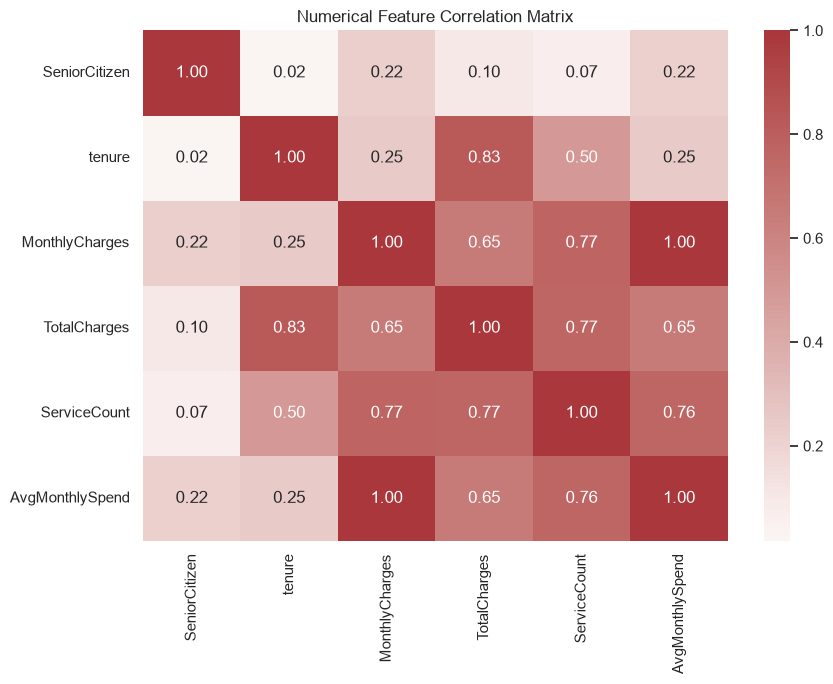

In [53]:
# Inspect numerical correlations to identify possible redundancy before modeling.
corr = analysis_df[numeric_cols + ["ServiceCount", "AvgMonthlySpend"]].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Preprocessing

The modeling pipeline handles missing values, scaling, and one-hot encoding inside cross-validation. This prevents preprocessing leakage from the validation/test data.

In [54]:
# Create the modeling dataset and target.
model_df = add_business_features(clean.copy())
X = model_df.drop(columns=[TARGET])
y = (model_df[TARGET] == "Yes").astype(int)

# Use a stratified split so the target proportion is preserved in both partitions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test churn rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 5634
Test rows: 1409
Training churn rate: 26.54 %
Test churn rate: 26.54 %


In [55]:
# Inspect the automatically identified numerical and categorical predictors.
X_model = X_train.drop(columns=[ID_COLUMN], errors="ignore")
numeric_features = X_model.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_model.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AvgMonthlySpend']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBand', 'ChargeBand']


## 8. Logistic Regression

The primary model is an interpretable Logistic Regression pipeline. The pipeline combines preprocessing and modeling so every transformation is learned only from training data.

In [56]:
# Build and fit the baseline Logistic Regression pipeline.
logistic = build_logistic_pipeline(X_train)
logistic.fit(X_train, y_train)

baseline_prob = logistic.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.50).astype(int)

baseline_metrics = evaluate_binary_model(y_test, baseline_pred, baseline_prob)
display(pd.DataFrame([baseline_metrics]).T.rename(columns={0: "value"}).round(4))

,value
accuracy,0.7991
precision,0.6574
recall,0.5080
f1,0.5732
roc_auc,0.8448
pr_auc,0.6488
log_loss,0.4167
brier_score,0.1366


In [57]:
# Tune Logistic Regression regularization strength using five-fold stratified cross-validation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=build_logistic_pipeline(X_train),
    param_grid={"model__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

best_logistic = grid.best_estimator_
logistic_prob = best_logistic.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.50).astype(int)

logistic_metrics = evaluate_binary_model(y_test, logistic_pred, logistic_prob)
display(pd.DataFrame([logistic_metrics]).T.rename(columns={0: "value"}).round(4))

Best parameters: {'model__C': 0.05}
Best CV ROC-AUC: 0.8473


,value
accuracy,0.8034
precision,0.6690
recall,0.5134
f1,0.5809
roc_auc,0.8447
pr_auc,0.6496
log_loss,0.4170
brier_score,0.1364


In [58]:
# Compare L1 and L2 regularization using the same leakage-safe preprocessing approach.
regularization_rows = []

for penalty in ["l1", "l2"]:
    pipe = build_logistic_pipeline(X_train, penalty=penalty, C=1.0)
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    metrics = evaluate_binary_model(y_test, pred, prob)
    metrics["penalty"] = penalty
    regularization_rows.append(metrics)

regularization_results = pd.DataFrame(regularization_rows)
display(regularization_results.round(4))

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score,penalty
0,0.7999,0.6586,0.5107,0.5753,0.8453,0.6509,0.4162,0.1364,l1
1,0.7991,0.6574,0.5080,0.5732,0.8448,0.6488,0.4167,0.1366,l2


In [59]:
# Evaluate class weighting as an explicit response to the imbalanced target.
weight_rows = []

for weight in [None, "balanced"]:
    pipe = build_logistic_pipeline(X_train, class_weight=weight)
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    metrics = evaluate_binary_model(y_test, pred, prob)
    metrics["class_weight"] = str(weight)
    weight_rows.append(metrics)

class_weight_results = pd.DataFrame(weight_rows)
display(class_weight_results.round(4))

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score,class_weight
0,0.7991,0.6574,0.5080,0.5732,0.8448,0.6488,0.4167,0.1366,None
1,0.7410,0.5076,0.8021,0.6218,0.8448,0.6499,0.4922,0.1659,balanced


## 9. Model Evaluation

We evaluate the final Logistic Regression with classification metrics, probability metrics, and a confusion matrix. No single metric is sufficient for churn analysis.

              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



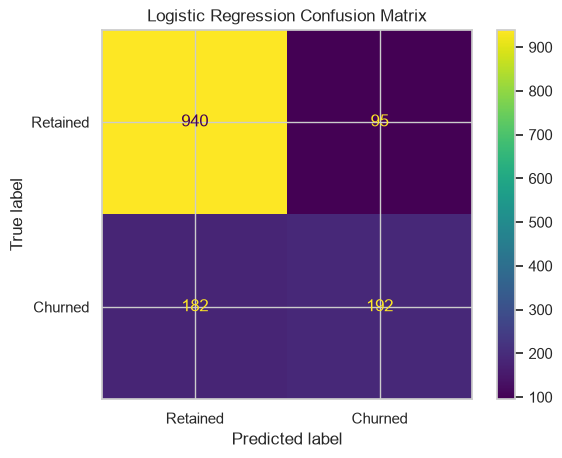

In [60]:
# Produce the full classification report for the tuned Logistic Regression.
print(classification_report(y_test, logistic_pred, target_names=["Retained", "Churned"]))

# Plot the confusion matrix to show false positives and false negatives.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=["Retained", "Churned"],
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

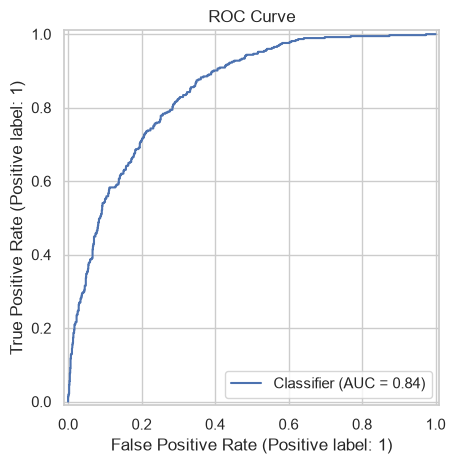

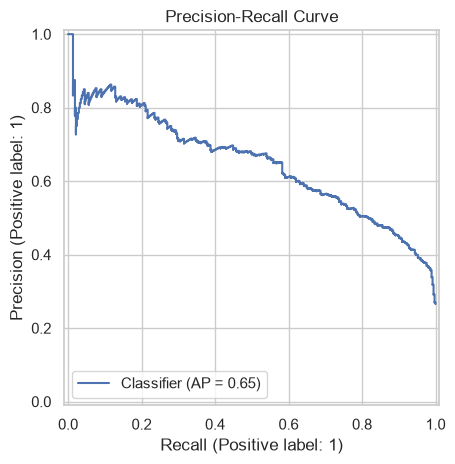

In [61]:
# Plot the ROC curve as an independent figure.
RocCurveDisplay.from_predictions(y_test, logistic_prob)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# Plot the Precision-Recall curve as an independent figure.
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, logistic_prob)
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## 10. Class Imbalance & Threshold Analysis

The default 0.50 threshold is a modeling convention, not automatically a business-optimal decision rule. The following analysis shows how changing the threshold changes precision, recall, F1, and the share of customers flagged.

,threshold,precision,recall,f1,flagged_rate
0,0.10,0.3995,0.9465,0.5619,0.6288
1,0.15,0.4404,0.9091,0.5934,0.5479
2,0.20,0.4804,0.8503,0.6139,0.4698
3,0.25,0.5042,0.8102,0.6215,0.4265
4,0.30,0.5350,0.7567,0.6268,0.3754
5,0.35,0.5614,0.7086,0.6265,0.3350
6,0.40,0.5874,0.6471,0.6158,0.2924
7,0.45,0.6173,0.5909,0.6038,0.2541
8,0.50,0.6690,0.5134,0.5809,0.2037
9,0.55,0.6857,0.4492,0.5428,0.1739


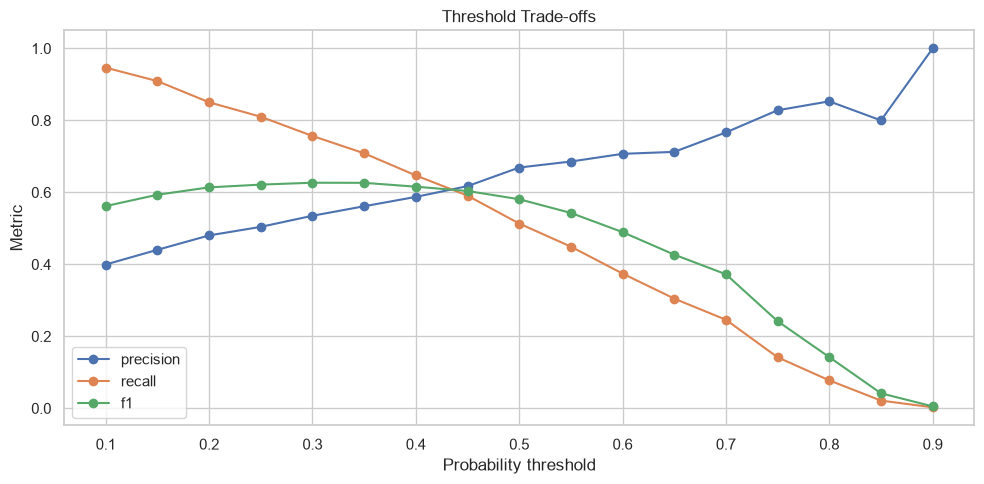

In [62]:
# Evaluate a range of probability thresholds.
thresholds = threshold_table(y_test, logistic_prob)
display(thresholds.round(4))

plt.figure(figsize=(10, 5))
for metric in ["precision", "recall", "f1"]:
    plt.plot(thresholds["threshold"], thresholds[metric], marker="o", label=metric)

plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Threshold Trade-offs")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Model Interpretation

Logistic Regression coefficients describe changes in log-odds. Exponentiating a coefficient gives an odds ratio. Interpretation is conditional on the model's other predictors and preprocessing.

In [63]:
# Extract coefficients, odds ratios, and absolute coefficient magnitude.
coef_df = coefficient_table(best_logistic)

print("Features most strongly associated with the fitted linear predictor:")
display(coef_df.head(20))

print("Largest positive coefficients:")
display(coef_df.sort_values("coefficient", ascending=False).head(10))

print("Largest negative coefficients:")
display(coef_df.sort_values("coefficient", ascending=True).head(10))

Features most strongly associated with the fitted linear predictor:


,feature,coefficient,odds_ratio,abs_coefficient
0,cat__Contract_Month-to-month,0.622390,1.863377,0.622390
1,cat__Contract_Two year,-0.580351,0.559702,0.580351
2,num__tenure,-0.543764,0.580559,0.543764
3,cat__TenureBand_0-6,0.488086,1.629194,0.488086
4,cat__InternetService_Fiber optic,0.324139,1.382840,0.324139
5,cat__PaymentMethod_Electronic check,0.262274,1.299882,0.262274
6,cat__InternetService_DSL,-0.256576,0.773696,0.256576
7,cat__OnlineSecurity_No,0.226123,1.253730,0.226123
8,cat__TenureBand_13-24,-0.212940,0.808204,0.212940
9,cat__TenureBand_25-48,-0.208393,0.811888,0.208393


Largest positive coefficients:


,feature,coefficient,odds_ratio,abs_coefficient
0,cat__Contract_Month-to-month,0.622390,1.863377,0.622390
3,cat__TenureBand_0-6,0.488086,1.629194,0.488086
4,cat__InternetService_Fiber optic,0.324139,1.382840,0.324139
5,cat__PaymentMethod_Electronic check,0.262274,1.299882,0.262274
7,cat__OnlineSecurity_No,0.226123,1.253730,0.226123
10,cat__TechSupport_No,0.204355,1.226733,0.204355
12,num__AvgMonthlySpend,0.195018,1.215333,0.195018
13,cat__PaperlessBilling_Yes,0.188335,1.207238,0.188335
16,num__MonthlyCharges,0.154401,1.166958,0.154401
18,cat__StreamingMovies_Yes,0.132857,1.142086,0.132857


Largest negative coefficients:


,feature,coefficient,odds_ratio,abs_coefficient
1,cat__Contract_Two year,-0.580351,0.559702,0.580351
2,num__tenure,-0.543764,0.580559,0.543764
6,cat__InternetService_DSL,-0.256576,0.773696,0.256576
8,cat__TenureBand_13-24,-0.212940,0.808204,0.212940
9,cat__TenureBand_25-48,-0.208393,0.811888,0.208393
11,cat__MultipleLines_No,-0.202098,0.817015,0.202098
14,cat__PaperlessBilling_No,-0.187454,0.829067,0.187454
15,cat__OnlineSecurity_Yes,-0.158560,0.853372,0.158560
17,cat__TechSupport_Yes,-0.136792,0.872152,0.136792
22,cat__PhoneService_Yes,-0.120546,0.886436,0.120546


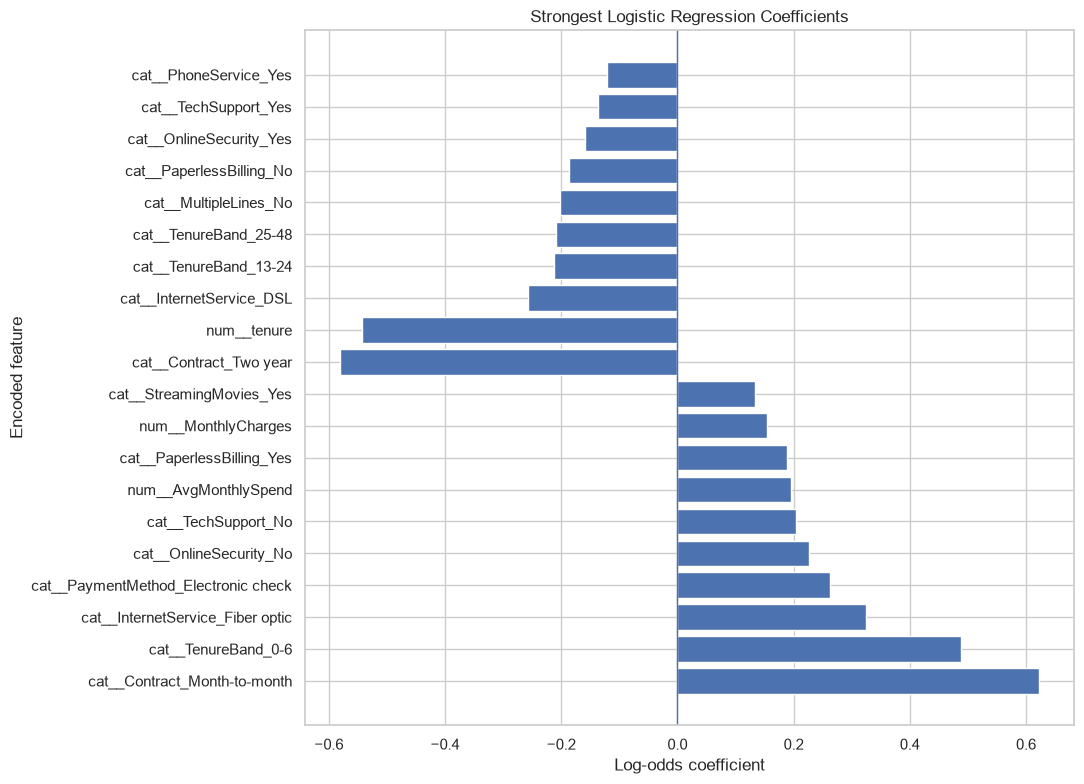

In [64]:
# Visualize the strongest positive and negative fitted coefficients with matplotlib.
top_pos = coef_df.sort_values("coefficient", ascending=False).head(10)
top_neg = coef_df.sort_values("coefficient", ascending=True).head(10)
coef_plot = pd.concat([top_pos, top_neg]).drop_duplicates()

plt.figure(figsize=(11, 8))
plt.barh(coef_plot["feature"].astype(str), coef_plot["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Log-odds coefficient")
plt.ylabel("Encoded feature")
plt.title("Strongest Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

## 12. Probability & Calibration

A churn model should produce probabilities that are useful, not only hard class labels. Calibration compares predicted probabilities with observed frequencies.

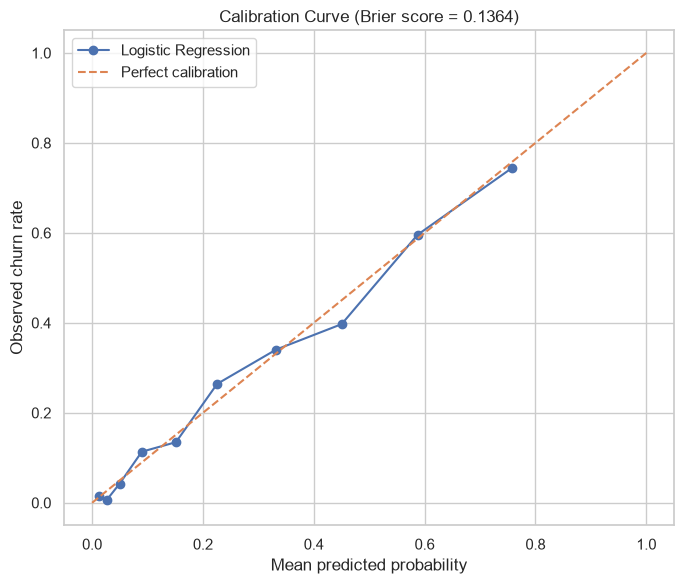

In [65]:
# Create a calibration curve and report Brier score.
fraction_positive, mean_predicted = calibration_curve(
    y_test,
    logistic_prob,
    n_bins=10,
    strategy="quantile",
)
brier = brier_score_loss(y_test, logistic_prob)

plt.figure(figsize=(7, 6))
plt.plot(mean_predicted, fraction_positive, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed churn rate")
plt.title(f"Calibration Curve (Brier score = {brier:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Customer Risk Segmentation

Risk groups are created from predicted probability thresholds for analytical use. They are not causal labels and should be validated against the business's actual retention costs and capacity.

In [66]:
# Attach predicted probabilities and risk groups to the held-out customers.
risk_test = X_test.copy()
risk_test["actual_churn"] = y_test.values
risk_test["churn_probability"] = logistic_prob
risk_test["risk_segment"] = risk_segments(logistic_prob).astype(str)

risk_summary = (
    risk_test.groupby("risk_segment", observed=False)
    .agg(
        customers=("actual_churn", "size"),
        actual_churners=("actual_churn", "sum"),
        average_probability=("churn_probability", "mean"),
    )
    .assign(
        observed_churn_rate=lambda d: 100 * d["actual_churners"] / d["customers"]
    )
)

display(risk_summary.round(4))

,customers,actual_churners,average_probability,observed_churn_rate
risk_segment,,,,
High,198,140,0.7234,70.7071
Low,880,91,0.1002,10.3409
Medium,331,143,0.4431,43.2024


In [67]:
# Profile high-risk customers using selected business characteristics.
high_risk_ids = risk_test.index[risk_test["risk_segment"] == "High"]
high_risk_profile = model_df.loc[high_risk_ids]

print("High-risk customer count:", len(high_risk_profile))
display(
    high_risk_profile[
        ["Contract", "InternetService", "tenure", "MonthlyCharges",
         "ServiceCount", "PaymentMethod", "Churn"]
    ].describe(include="all").T
)

High-risk customer count: 198


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Contract,198,2,Month-to-month,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,198,2,Fiber optic,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,198.0,NaN,NaN,NaN,6.126263,7.051602,1.0,2.0,3.5,7.0,37.0
MonthlyCharges,198.0,NaN,NaN,NaN,80.481313,15.4992,24.8,74.35,79.8,90.6875,111.4
ServiceCount,198.0,NaN,NaN,NaN,2.262626,1.234741,0.0,1.0,2.0,3.0,6.0
PaymentMethod,198,4,Electronic check,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,198,2,Yes,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 14. Business Impact Analysis

The model can support prioritization by estimating how many customers fall into each risk group and how much observed monthly-charge exposure exists in those groups. This is an analytical exposure measure, not a forecast of lost revenue.

In [68]:
# Estimate customer volume and monthly-charge exposure by predicted risk segment.
business_impact = (
    risk_test.assign(
        monthly_charges=model_df.loc[risk_test.index, "MonthlyCharges"].values
    )
    .groupby("risk_segment", observed=False)
    .agg(
        customers=("actual_churn", "size"),
        churners=("actual_churn", "sum"),
        avg_monthly_charge=("monthly_charges", "mean"),
        monthly_charge_exposure=("monthly_charges", "sum"),
    )
    .assign(
        customer_share=lambda d: 100 * d["customers"] / d["customers"].sum(),
        observed_churn_rate=lambda d: 100 * d["churners"] / d["customers"],
    )
)

display(business_impact.round(2))

,customers,churners,avg_monthly_charge,monthly_charge_exposure,customer_share,observed_churn_rate
risk_segment,,,,,,
High,198,140,80.48,15935.30,14.05,70.71
Low,880,91,56.63,49836.35,62.46,10.34
Medium,331,143,74.11,24529.55,23.49,43.20


## 15. Model Robustness & Reliability

We evaluate cross-validation stability using multiple metrics. This reduces reliance on a single train/test split when describing expected model behavior.

In [69]:
# Estimate cross-validation performance of the tuned Logistic Regression pipeline.
cv_metrics = cross_validate(
    best_logistic,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

robustness = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean": [
        cv_metrics["test_accuracy"].mean(),
        cv_metrics["test_precision"].mean(),
        cv_metrics["test_recall"].mean(),
        cv_metrics["test_f1"].mean(),
        cv_metrics["test_roc_auc"].mean(),
    ],
    "std": [
        cv_metrics["test_accuracy"].std(),
        cv_metrics["test_precision"].std(),
        cv_metrics["test_recall"].std(),
        cv_metrics["test_f1"].std(),
        cv_metrics["test_roc_auc"].std(),
    ],
})
display(robustness.round(4))

,metric,mean,std
0,accuracy,0.8076,0.0108
1,precision,0.6755,0.0287
2,recall,0.5304,0.0338
3,f1,0.5936,0.0264
4,roc_auc,0.8473,0.0109


## 16. Model Comparison

Decision Tree and Random Forest are included as reference models. The comparison is descriptive: predictive performance and interpretability should be considered together rather than treating one metric as a universal winner.

In [70]:
# Fit two tree-based reference models on the same encoded feature matrix.
# The preprocessing is reused through a pipeline so categorical handling remains consistent.
tree_pipe = Pipeline([
    ("preprocessor", best_logistic.named_steps["preprocessor"]),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])

forest_pipe = Pipeline([
    ("preprocessor", best_logistic.named_steps["preprocessor"]),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

comparison_rows = []
for name, pipe in [
    ("Logistic Regression", best_logistic),
    ("Decision Tree", tree_pipe),
    ("Random Forest", forest_pipe),
]:
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    metrics = evaluate_binary_model(y_test, pred, prob)
    metrics["model"] = name
    comparison_rows.append(metrics)

comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison.round(4))

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score
model,,,,,,,,
Logistic Regression,0.8034,0.6690,0.5134,0.5809,0.8447,0.6496,0.4170,0.1364
Decision Tree,0.7559,0.5279,0.7594,0.6228,0.8333,0.6251,0.5459,0.1697
Random Forest,0.7594,0.5318,0.7834,0.6335,0.8430,0.6555,0.4771,0.1593


## 17. Final Business Analysis

The following cells consolidate the evidence into compact tables suitable for the project report and README.

In [71]:
# Build a final evidence table from the main analytical outputs.
final_metrics = pd.DataFrame([logistic_metrics], index=["Logistic Regression"]).T
final_metrics.columns = ["value"]

print("Final holdout performance")
display(final_metrics.round(4))

print("Top categorical associations by chi-square p-value")
display(chi_results.head(10))

print("Numerical associations")
display(point_results)

Final holdout performance


,value
accuracy,0.8034
precision,0.6690
recall,0.5134
f1,0.5809
roc_auc,0.8447
pr_auc,0.6496
log_loss,0.4170
brier_score,0.1364


Top categorical associations by chi-square p-value


,feature,chi2,p_value,degrees_of_freedom
12,Contract,1184.596572,5.863038e-258,2
6,OnlineSecurity,849.998968,2.661150e-185,2
9,TechSupport,828.197068,1.443084e-180,2
5,InternetService,732.309590,9.571788e-160,2
14,PaymentMethod,648.142327,3.682355e-140,3
7,OnlineBackup,601.812790,2.079759e-131,2
8,DeviceProtection,558.419369,5.505219e-122,2
11,StreamingMovies,375.661479,2.667757e-82,2
10,StreamingTV,374.203943,5.528994e-82,2
13,PaperlessBilling,258.277649,4.073355e-58,1


Numerical associations


,feature,point_biserial_r,p_value
1,tenure,-0.352229,7.999058e-205
3,TotalCharges,-0.199484,4.876866e-64
2,MonthlyCharges,0.193356,2.706646e-60
0,SeniorCitizen,0.150889,3.839860e-37


In [72]:
# Generate a compact executive summary using observed dataset/model results.
churn_rate = y.mean() * 100
best_cv_auc = grid.best_score_
test_auc = logistic_metrics["roc_auc"]
test_pr_auc = logistic_metrics["pr_auc"]

print(f"Customers analyzed: {len(model_df):,}")
print(f"Observed churn rate: {churn_rate:.2f}%")
print(f"Best 5-fold CV ROC-AUC: {best_cv_auc:.4f}")
print(f"Holdout ROC-AUC: {test_auc:.4f}")
print(f"Holdout PR-AUC: {test_pr_auc:.4f}")
print(f"Holdout F1 at threshold 0.50: {logistic_metrics['f1']:.4f}")
print(f"Holdout Brier score: {logistic_metrics['brier_score']:.4f}")

Customers analyzed: 7,043
Observed churn rate: 26.54%
Best 5-fold CV ROC-AUC: 0.8473
Holdout ROC-AUC: 0.8447
Holdout PR-AUC: 0.6496
Holdout F1 at threshold 0.50: 0.5809
Holdout Brier score: 0.1364


## 18. Project Conclusion

### What this project establishes

- The dataset can be analyzed as a binary customer-churn problem.
- Data quality must be handled explicitly, especially `TotalCharges`.
- Churn patterns can be examined across contract, service, billing, demographic, and tenure dimensions.
- Statistical tests quantify associations but do not prove causality.
- Logistic Regression provides an interpretable probability model.
- Cross-validation and threshold analysis are important because churn is not evenly distributed across classes.
- Coefficients and odds ratios provide an interpretable view of the fitted model.
- Predicted probabilities can be grouped into analytical risk segments.
- Business impact should consider customer volume and financial exposure rather than accuracy alone.
- Decision Tree and Random Forest provide useful reference points for model-comparison analysis.

### Limitations

The dataset is observational. Therefore, model associations should not be interpreted as causal effects. Retention actions would require additional business information such as retention costs, customer lifetime value, intervention history, complaints, service incidents, and post-intervention outcomes.

### Reproducibility

Run the notebook from the project root with the supplied CSV under `data/raw/`, or run `python src/train_model.py` after installing `requirements.txt`.